In [9]:
import pandas as pd
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt

In [3]:
files = sorted(glob.glob('AMeDAS_data/daily/47646/*'))
df = pd.concat([pd.read_csv(f, index_col=0, parse_dates=True) for f in files])
df = df.replace(-999, np.nan)
dy = df.groupby(df.index.year)
dm = df.groupby([df.index.year,df.index.month ])
prcp = dm.sum().loc[:,'precip-accum_mm']
temp = dm.mean().loc[:,'temp_C']
do = pd.concat([prcp, temp], axis=1)
do.index = pd.to_datetime({'year': do.index.get_level_values(0), 'month': do.index.get_level_values(1), 'day': 1})
do.to_csv('Tsukuba_mon.csv')

In [7]:
dat = pd.read_csv('Tsukuba_mon.csv', index_col=0, parse_dates=True)
prcp, temp = dat.loc[:,'precip-accum_mm'], dat.loc[:,'temp_C']

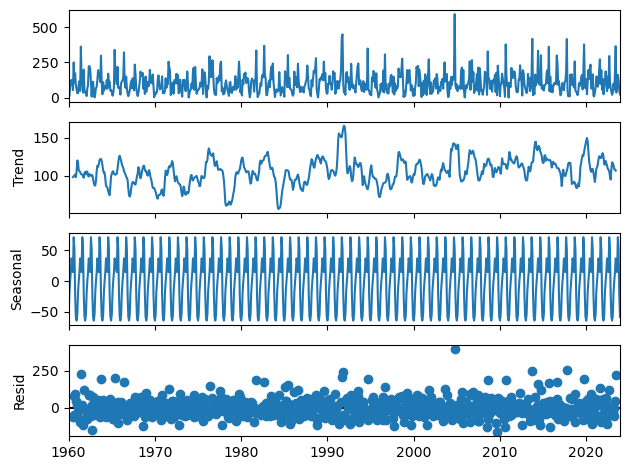

In [11]:
import statsmodels.api as sm
# Assuming 'prcp' is the monthly precipitation data, a 1D array with monthly values 
# Create a time series index
date_range = prcp.index
# Create a pandas Series with the time index
prcp_series = pd.Series(prcp.values, index=date_range)
# Perform seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(prcp_series, model='additive', period=12)
# Plot the decomposed components
decomposition.plot()
plt.show()

In [17]:
# Extract the trend and residual components
trend = decomposition.trend.dropna()  # drop NaN values at the ends
trend_detrend = trend - np.mean(trend)
residual = decomposition.resid.dropna()
seasonal = decomposition.seasonal.dropna()

In [22]:
trend_detrend.index

1960-07-01    -7.229614
1960-08-01    -6.158780
1960-09-01    -4.721280
1960-10-01    -4.104614
1960-11-01    -7.412947
                ...    
2023-02-01    10.782886
2023-03-01     8.324553
2023-04-01     3.095386
2023-05-01     2.782886
2023-06-01     1.324553
Name: trend, Length: 755, dtype: float64

In [57]:
files = sorted(glob.glob('timeseries/*'))
dall = []
for f in files[:]:
    df = pd.read_csv(f, index_col=0, parse_dates=True)
    is_monthly = is_monthly = df.index.to_series().diff().dropna().apply(lambda x: 28 <= x.days <= 31).all()
    if not is_monthly: continue
    dall.append(df)
    #print(f)

<Axes: xlabel='date'>

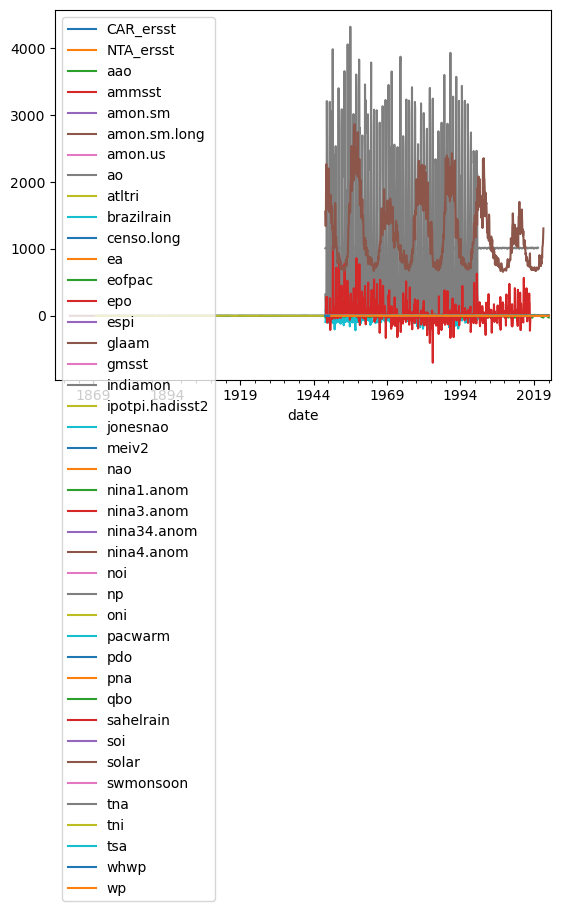

In [70]:
# Convert all DataFrames to have a consistent year-month index
# Standardize indices to a consistent year-month format for all DataFrames
for i in range(len(dall)):
    if not isinstance(dall[i].index, pd.PeriodIndex):
        dall[i].index = dall[i].index.to_period('M')
# Concatenate all DataFrames along the index axis
combined_df = pd.concat(dall, axis=1).sort_index()
# Convert the period index back to datetime index for easier manipulation
combined_df.index = combined_df.index.to_timestamp()
# Reset the index to remove duplicate indices, in case needed
#combined_df = combined_df.reset_index().drop_duplicates(subset='index').set_index('index')
# Print some information about the combined DataFrame
#print(f"Combined DataFrame with shape: {combined_df.shape}")
#print(combined_df.head())
combined_df.plot()

In [72]:
common_dates = trend_detrend.index.to_period('M').intersection(combined_df.index.to_period('M'))
common_dates

PeriodIndex(['1960-07', '1960-08', '1960-09', '1960-10', '1960-11', '1960-12',
             '1961-01', '1961-02', '1961-03', '1961-04',
             ...
             '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02',
             '2023-03', '2023-04', '2023-05', '2023-06'],
            dtype='period[M]', length=755)

In [74]:
trend_detrend_filtered = trend_detrend[trend_detrend.index.to_period('M').isin(common_dates)]
df_filtered = combined_df[combined_df.index.to_period('M').isin(common_dates)]

<Axes: xlabel='date'>

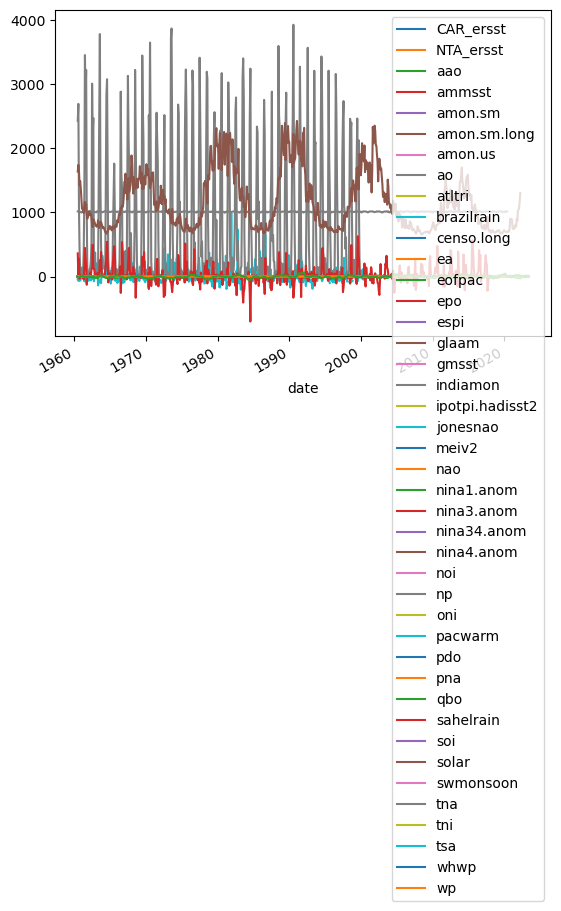

In [78]:
df_filtered.plot()
trend_detrend_filtered.plot()

In [79]:
x = df_filtered
y = trend_detrend_filtered

In [88]:
# Display data information
#print(x.info())
# Display the first few rows of data
#print(x.head())
# Convert the index to period ('M') to standardize as monthly
#x.index = x.index.to_period('M')
# Fill missing values with the mean of each column
x_filled = x.fillna(x.mean())
# Drop rows with any missing values
x_dropped = x.dropna()

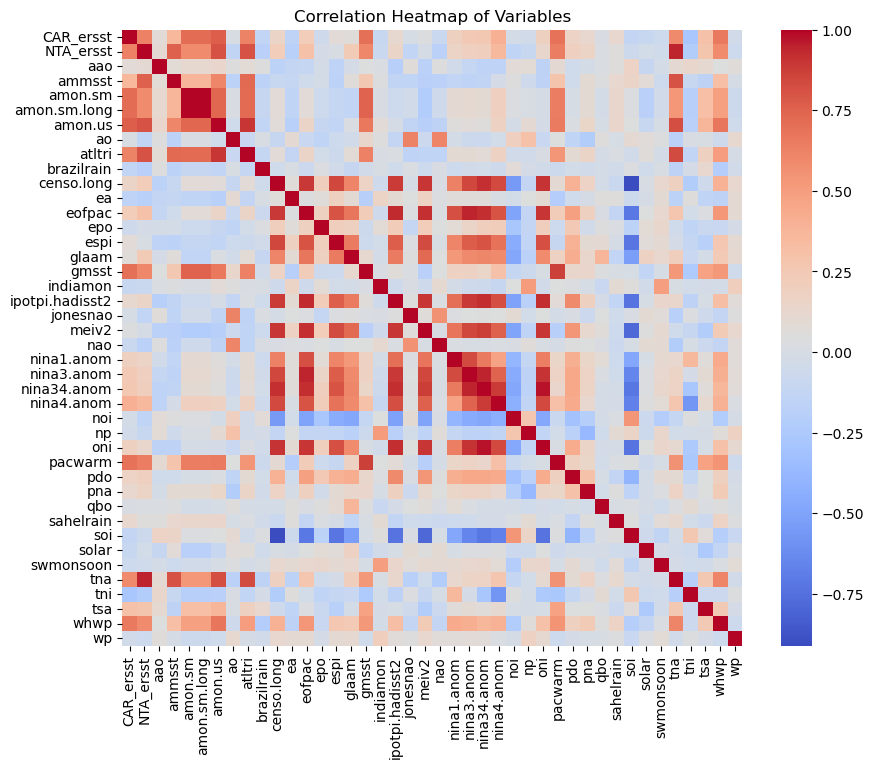

In [98]:
# Calculate the Pearson correlation between all columns
correlation_matrix = x.corr()
# Display the correlation matrix
#print(correlation_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".1f")
plt.title('Correlation Heatmap of Variables')
plt.show()

In [106]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assuming x and y are already defined and aligned

# Step 1: Handle missing values in x using SimpleImputer
imputer = SimpleImputer(strategy='mean')
x_imputed = imputer.fit_transform(x)

# Step 2: Standardize x and y
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_scaled = scaler_x.fit_transform(x_imputed)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# Step 3: Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

# Step 4: Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Make predictions and evaluate the model
y_pred = model.predict(X_test)

# Rescale predictions and actual values back to original scale for interpretation
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Evaluation metrics
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f'Mean Squared Error: {mse:.3f}')
print(f'R^2 Score: {r2:.3f}')


Mean Squared Error: 297.207
R^2 Score: 0.085


Mean Squared Error: 297.207
R^2 Score: 0.085


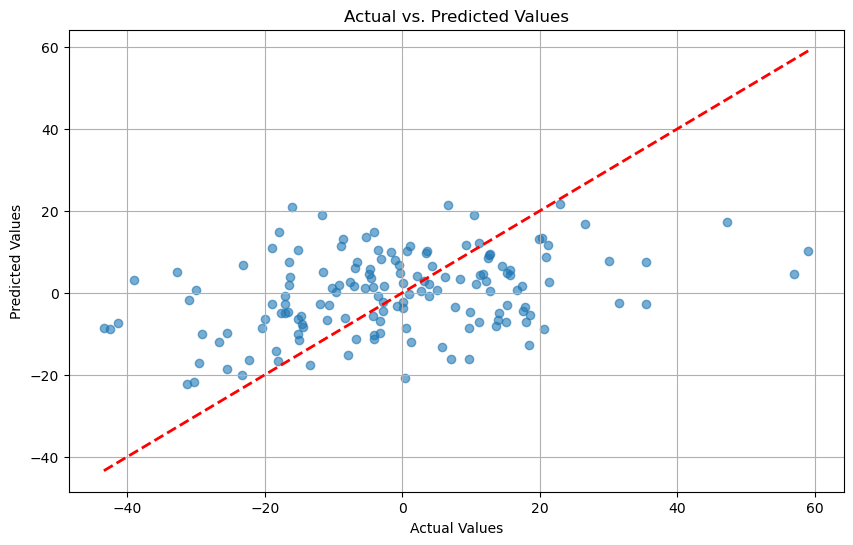

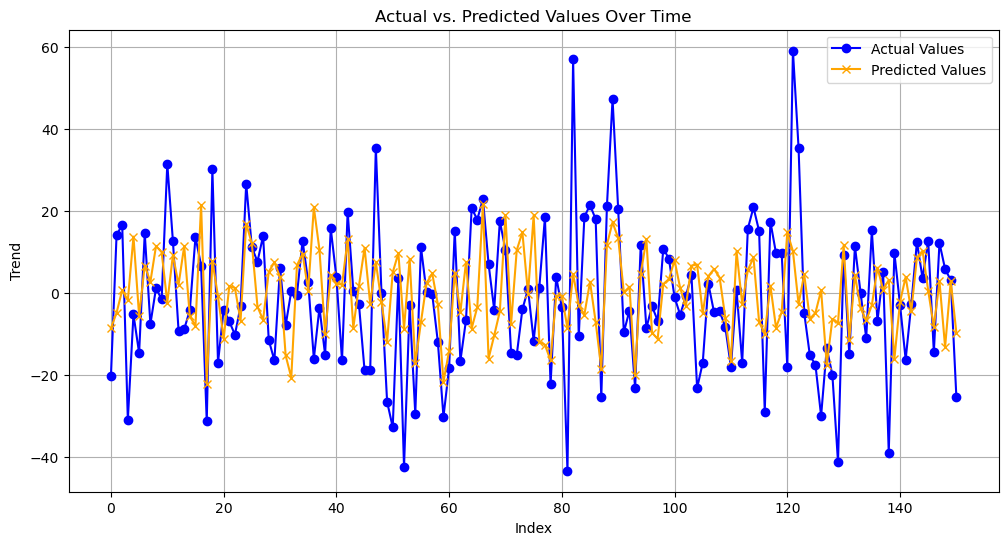

In [107]:
import matplotlib.pyplot as plt

# Step 5: Make predictions and evaluate the model
y_pred = model.predict(X_test)

# Rescale predictions and actual values back to original scale for interpretation
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

# Evaluation metrics
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f'Mean Squared Error: {mse:.3f}')
print(f'R^2 Score: {r2:.3f}')

# Visualization: Scatter Plot of Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red', linestyle='--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()

# Visualization: Line Plot of Actual vs. Predicted Values Over Time
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual Values', color='blue', linestyle='-', marker='o')
plt.plot(y_pred_original, label='Predicted Values', color='orange', linestyle='-', marker='x')
plt.xlabel('Index')
plt.ylabel('Trend')
plt.title('Actual vs. Predicted Values Over Time')
plt.legend()
plt.grid(True)
plt.show()


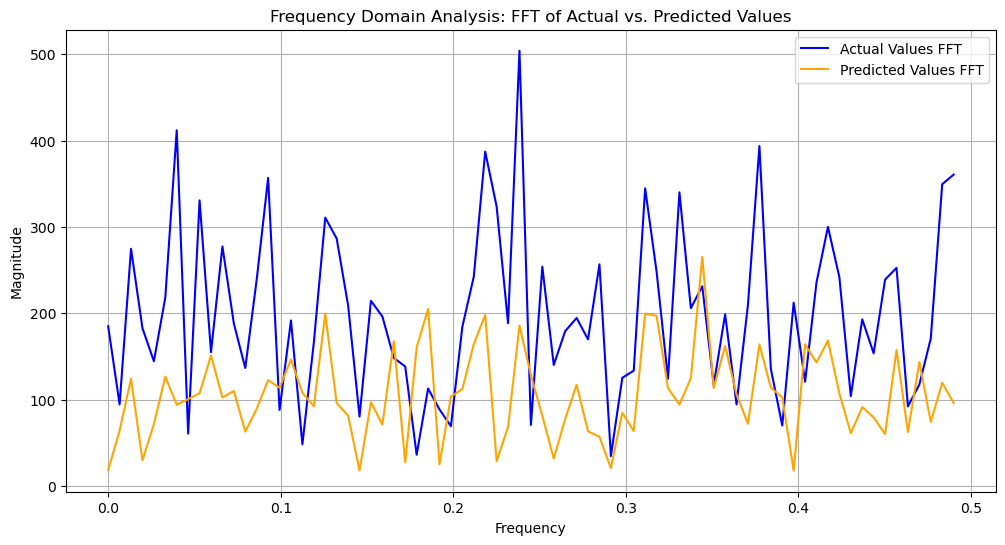

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Perform FFT on actual and predicted values
fft_actual = np.fft.fft(y_test_original)
fft_predicted = np.fft.fft(y_pred_original)

# Step 2: Compute the frequencies
n = len(y_test_original)
frequencies = np.fft.fftfreq(n)

# Step 3: Take the absolute value to get the magnitude of the frequency components
magnitude_actual = np.abs(fft_actual)
magnitude_predicted = np.abs(fft_predicted)

# Step 4: Plot the frequency components
plt.figure(figsize=(12, 6))
plt.plot(frequencies[:n // 2], magnitude_actual[:n // 2], label='Actual Values FFT', color='blue')
plt.plot(frequencies[:n // 2], magnitude_predicted[:n // 2], label='Predicted Values FFT', color='orange')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.title('Frequency Domain Analysis: FFT of Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define extreme values as values above the 90th percentile or below the 10th percentile
threshold_high = np.percentile(y_test_original, 90)
threshold_low = np.percentile(y_test_original, 10)

# Create boolean masks for extreme values
extreme_mask = (y_test_original >= threshold_high) | (y_test_original <= threshold_low)

# Extract extreme values for actual and predicted
y_extreme_actual = y_test_original[extreme_mask]
y_extreme_predicted = y_pred_original[extreme_mask]


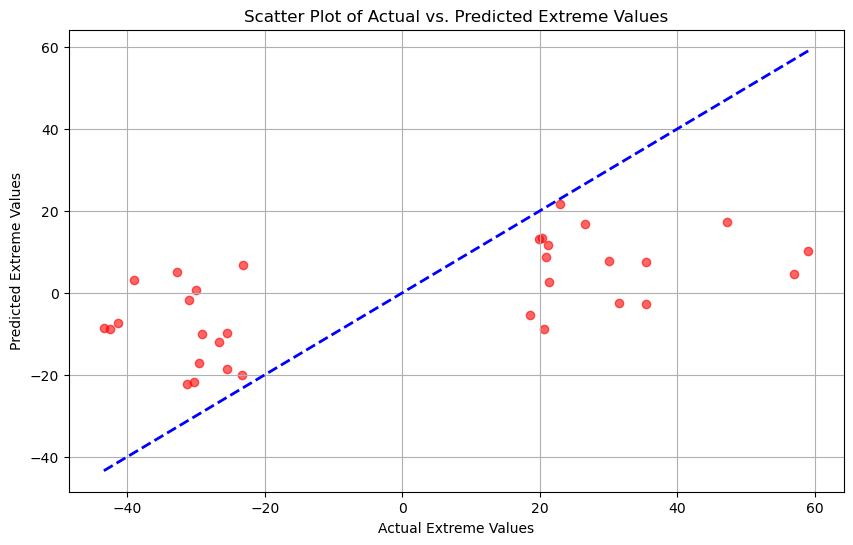

Mean Absolute Error for Extreme Values: 22.943
Root Mean Squared Error for Extreme Values: 26.647


/Users/doan/anaconda3_2023.09-0/envs/wrf/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [111]:
plt.figure(figsize=(10, 6))
plt.scatter(y_extreme_actual, y_extreme_predicted, alpha=0.6, color='red')
plt.plot([y_extreme_actual.min(), y_extreme_actual.max()],
         [y_extreme_actual.min(), y_extreme_actual.max()],
         color='blue', linestyle='--', lw=2)
plt.xlabel('Actual Extreme Values')
plt.ylabel('Predicted Extreme Values')
plt.title('Scatter Plot of Actual vs. Predicted Extreme Values')
plt.grid(True)
plt.show()

# Calculate Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for extreme values
mae_extreme = mean_absolute_error(y_extreme_actual, y_extreme_predicted)
rmse_extreme = mean_squared_error(y_extreme_actual, y_extreme_predicted, squared=False)

print(f'Mean Absolute Error for Extreme Values: {mae_extreme:.3f}')
print(f'Root Mean Squared Error for Extreme Values: {rmse_extreme:.3f}')


In [112]:
from sklearn.metrics import precision_score, recall_score

# Convert extreme threshold to binary classification: 1 for extreme, 0 otherwise
y_actual_binary = ((y_test_original >= threshold_high) | (y_test_original <= threshold_low)).astype(int)
y_pred_binary = ((y_pred_original >= threshold_high) | (y_pred_original <= threshold_low)).astype(int)

# Calculate precision and recall
precision = precision_score(y_actual_binary, y_pred_binary)
recall = recall_score(y_actual_binary, y_pred_binary)

print(f'Precision for Extreme Events: {precision:.3f}')
print(f'Recall for Extreme Events: {recall:.3f}')


Precision for Extreme Events: 0.200
Recall for Extreme Events: 0.031


In [113]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Define and train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
print(f'Random Forest RMSE: {rmse_rf:.3f}')


Random Forest RMSE: 0.746


/Users/doan/anaconda3_2023.09-0/envs/wrf/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


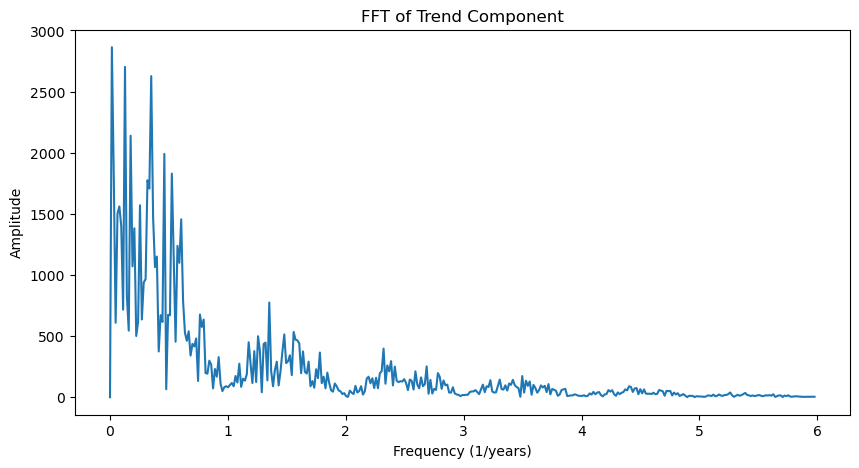

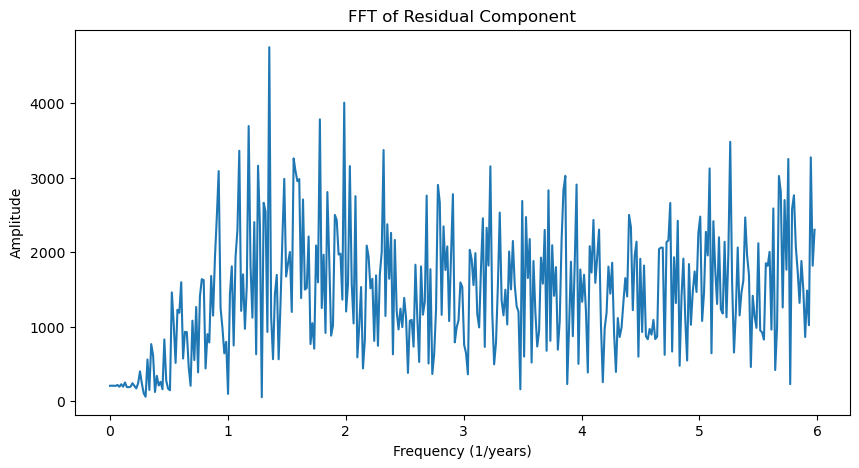

In [14]:


# Step 2: Apply FFT to Trend
trend_fft_values = np.fft.fft(trend_detrend)
trend_frequencies = np.fft.fftfreq(len(trend_detrend), d=1/12)[:len(trend)//2]
trend_amplitudes = np.abs(trend_fft_values)[:len(trend_detrend)//2]

# Step 3: Apply FFT to Residual
residual_fft_values = np.fft.fft(residual)
residual_frequencies = np.fft.fftfreq(len(residual), d=1/12)[:len(residual)//2]
residual_amplitudes = np.abs(residual_fft_values)[:len(residual)//2]

# Plot FFT of Trend
plt.figure(figsize=(10, 5))
plt.plot(trend_frequencies, trend_amplitudes)
plt.xlabel('Frequency (1/years)')
plt.ylabel('Amplitude')
plt.title('FFT of Trend Component')
plt.show()

# Plot FFT of Residual
plt.figure(figsize=(10, 5))
plt.plot(residual_frequencies, residual_amplitudes)
plt.xlabel('Frequency (1/years)')
plt.ylabel('Amplitude')
plt.title('FFT of Residual Component')
plt.show()

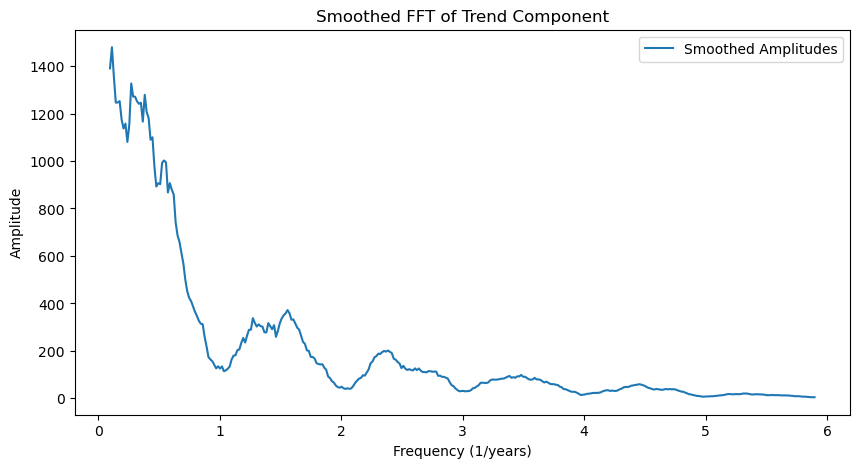

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have already calculated the FFT values for the detrended trend component:
# trend_frequencies, trend_amplitudes

# Define a window size for the moving average (you can adjust this)
window_size = 12

# Apply a moving average to the amplitudes
smoothed_trend_amplitudes = pd.Series(trend_amplitudes).rolling(window=window_size, center=True).mean()

# Plot the smoothed FFT of the trend component
plt.figure(figsize=(10, 5))
plt.plot(trend_frequencies, smoothed_trend_amplitudes, label="Smoothed Amplitudes")
plt.xlabel('Frequency (1/years)')
plt.ylabel('Amplitude')
plt.title('Smoothed FFT of Trend Component')
plt.legend()
plt.show()


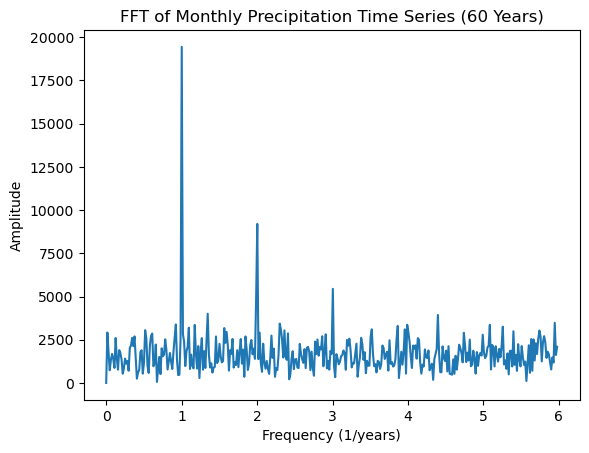

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'prcp' is your monthly time series data (1D array of length 720)
# prcp = np.array([...])  # 720 monthly values for 60 years
prcp_detrended = prcp - np.mean(prcp)

# Apply FFT
fft_values = np.fft.fft(prcp_detrended)

# Get the corresponding frequencies
n = len(prcp_detrended)
frequencies = np.fft.fftfreq(n, d=1/12)[:n//2]  # Keep only the positive frequencies (1/year)

# Calculate the amplitude of the FFT and keep only the first half
amplitudes = np.abs(fft_values)[:n//2]

# Plot the amplitude spectrum for the first half
plt.plot(frequencies, amplitudes)
plt.xlabel('Frequency (1/years)')
plt.ylabel('Amplitude')
plt.title('FFT of Monthly Precipitation Time Series (60 Years)')
#plt.xlim([0,10])
plt.show()


In [42]:
frequencies, amplitudes

(array([0.        , 0.01564537, 0.03129074, 0.04693611, 0.06258149,
        0.07822686, 0.09387223, 0.1095176 , 0.12516297, 0.14080834,
        0.15645372, 0.17209909, 0.18774446, 0.20338983, 0.2190352 ,
        0.23468057, 0.25032595, 0.26597132, 0.28161669, 0.29726206,
        0.31290743, 0.3285528 , 0.34419817, 0.35984355, 0.37548892,
        0.39113429, 0.40677966, 0.42242503, 0.4380704 , 0.45371578,
        0.46936115, 0.48500652, 0.50065189, 0.51629726, 0.53194263,
        0.54758801, 0.56323338, 0.57887875, 0.59452412, 0.61016949,
        0.62581486, 0.64146023, 0.65710561, 0.67275098, 0.68839635,
        0.70404172, 0.71968709, 0.73533246, 0.75097784, 0.76662321,
        0.78226858, 0.79791395, 0.81355932, 0.82920469, 0.84485007,
        0.86049544, 0.87614081, 0.89178618, 0.90743155, 0.92307692,
        0.93872229, 0.95436767, 0.97001304, 0.98565841, 1.00130378,
        1.01694915, 1.03259452, 1.0482399 , 1.06388527, 1.07953064,
        1.09517601, 1.11082138, 1.12646675, 1.14

<Axes: >

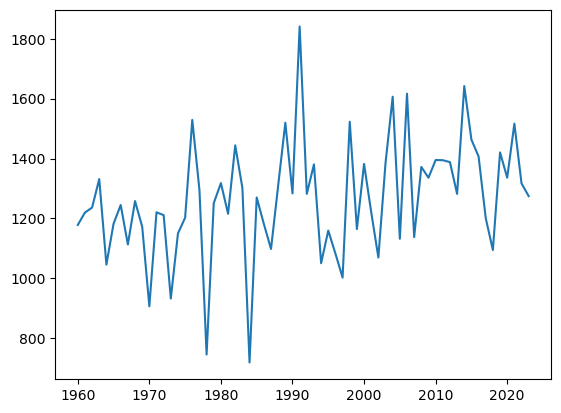

In [29]:
dy.sum().loc[:,'precip-accum_mm'].plot()